### Osteoporosis prediction

## Objective

OP reference article: https://www.niams.nih.gov/health-topics/osteoporosis

## Dataset

URL: https://www.kaggle.com/datasets/jehanbhathena/bone-mineral-density/data

### Columns explanation by categories

Demographics and body metrics:
- Gender: Sex (coded)
- Age: Age (years)
- Height: Height (cm)
- Weight: Weight (kg)
- BMI: Body mass index (weight/height²)

Bone density (DXA):
- L1-4: Bone density of lumbar spine (L1–L4)
- L1.4T: T-score of lumbar spine
- FN: Bone density of femoral neck (hip)
- FNT: T-score of femoral neck
- TL: Bone density of total hip
- TLT: T-score of total hip

Liver & kidney blood tests:
- ALT: Liver enzyme
- AST: Liver enzyme
- BUN: Blood urea nitrogen (kidney function)
- CREA: Creatinine (kidney function)
- URIC: Uric acid level

Metabolic & lipid tests:
- FBG: Fasting blood glucose
- HDL-C: “Good” cholesterol
- LDL-C: “Bad” cholesterol

Minerals & hormones:
- Ca: Blood calcium
- P: Blood phosphorus
- Mg: Blood magnesium
- Calsium: Calcium supplement use (yes/no)
- Calcitriol: Vitamin D hormone use (yes/no)

Bone medications:
- Bisphosphonate: Osteoporosis drug use (yes/no)
- Calcitonin: Bone hormone drug use (yes/no)

Diseases (yes/no):
- HTN: Hypertension
- COPD: Chronic lung disease
- DM: Diabetes
- Hyperlipidaemia: High blood lipids
- Hyperuricemia: High uric acid
- AS: Atherosclerosis
- VT: Vascular thrombosis
- VD: Vascular disease
- OP: Osteoporosis
- CAD: Coronary artery disease
- CKD: Chronic kidney disease
- Fracture: History of fracture

Lifestyle (yes/no):
- Smoking
- Drinking

# 1. Environment setup

This notebook requires Python >= 3.11.

Dependency versions are pinned to ensure running consistency over time.

In [16]:
from PIL.ImageChops import offset
!pip install --quiet pandas==2.3.3
!pip install --quiet missingno==0.5.2
!pip install --quiet matplotlib==3.10.8
!pip install --quiet seaborn==0.13.2
!pip install --quiet scikit-learn==1.8.0


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [17]:
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Data analysis

In [18]:
data = pd.read_csv("./UA.csv", sep=",")
data.head(10)

,Gender,Age,Height,Weight,BMI,L1-4,L1.4T,FN,FNT,TL,...,Hyperuricemia,AS,VT,VD,OP,CAD,CKD,Fracture,Smoking,Drinking
0,2,61.9,164.0,47.0,17.474717,0.894,-2.4,0.6895,-2.95,0.7130,...,1,1,0,1,1,1,0,0,1,0
1,2,55.0,162.0,54.0,20.576132,1.333,1.3,0.9130,-1.30,1.0675,...,1,1,0,1,1,0,1,0,0,0
2,2,44.0,160.0,54.0,21.093750,1.157,-0.2,0.5190,-3.85,0.5770,...,1,1,0,1,1,1,0,0,0,0
3,1,64.7,158.0,59.0,23.634033,0.948,-2.3,0.7920,-2.15,0.9050,...,1,1,0,1,1,1,0,0,1,1
4,1,88.5,167.0,60.0,21.513859,1.114,-0.9,0.8250,-1.90,0.9385,...,1,1,0,1,1,1,0,0,1,0
5,1,73.0,169.0,65.0,22.758307,0.956,-2.2,0.6965,-2.35,0.7550,...,1,1,0,1,1,0,1,0,0,0
6,1,61.5,168.0,60.0,21.258503,1.249,0.2,0.7385,-2.55,0.9200,...,1,1,0,1,1,1,0,0,0,0
7,2,52.9,160.0,51.0,19.921875,1.093,-0.7,0.7345,-2.60,0.8120,...,1,0,0,1,1,1,0,0,0,0
8,2,53.1,165.0,60.0,22.038567,1.036,-1.2,0.7895,-2.15,0.8270,...,1,1,0,0,1,0,0,0,1,1
9,2,86.0,155.0,65.0,27.055151,1.099,-0.7,0.6885,-2.95,0.7965,...,1,1,0,0,1,0,0,0,1,1


In [20]:
"""
This dataset has too many columns that are not necessarily relevant for OP prediction.
The following ones will be dropped:
    - Liver & kidney labs (ALT, AST, BUN, CREA, URIC): not directly related to OP
    - Bone medications (Calsium, Calcitriol, Bisphosphonate, Calcitonin): could already indicate that patient has OP, which is not good for training because it could miss interpret a patient that is receiving the diagnosis for the first time
    - Other diseases (HTN, COPD, DM, Hyperlipidaemia, Hyperuricemia, AS, VT, VD, CAD, CKD): not relevant for the context

The following columns will be kept because they are closely related to bone health and risk factors:
    - Target: OP (osteoporosis status)
    - Demographics and body metrics: Gender, Age, Height, Weight, BMI
    - Bone density measurements: L1-4, L1.4T, FN, FNT, TL, TLT
    - Mineral and metabolic labs: Ca, P, Mg, FBG, HDL-C, LDL-C
    - Lifestyle and history: Smoking, Drinking, Fracture
"""
data.drop(axis=1, inplace=True, labels=[
    "ALT", "AST", "BUN", "CREA", "URIC",
    "Calsium", "Calcitriol", "Bisphosphonate", "Calcitonin",
    "HTN", "COPD", "DM", "Hyperlipidaemia", "Hyperuricemia", "AS", "VT", "VD", "CAD", "CKD",
])

In [21]:
"""
We can see some of the binary/flag columns and some numeric columns.

We can't tell the gender in a human readable way because we don't have its equivalent label column, but we could use the body and bone measurement densities to infer the value. Note: In a real case scenario I imagine the source of data would provide this clarification instead.

The numeric columns have values that vary considerably, from -3.85 up to 169.0. This can require scaling later on, depending on the model we choose to use, like LinearRegression or KNN for example.
"""
data.head(10)

,Gender,Age,Height,Weight,BMI,L1-4,L1.4T,FN,FNT,TL,...,FBG,HDL-C,LDL-C,Ca,P,Mg,OP,Fracture,Smoking,Drinking
0,2,61.9,164.0,47.0,17.474717,0.894,-2.4,0.6895,-2.95,0.7130,...,4.55,1.16,2.06,2.15,1.04,0.76,1,0,1,0
1,2,55.0,162.0,54.0,20.576132,1.333,1.3,0.9130,-1.30,1.0675,...,3.89,1.22,2.35,2.15,1.11,0.96,1,0,0,0
2,2,44.0,160.0,54.0,21.093750,1.157,-0.2,0.5190,-3.85,0.5770,...,4.66,1.54,1.65,2.18,1.10,0.89,1,0,0,0
3,1,64.7,158.0,59.0,23.634033,0.948,-2.3,0.7920,-2.15,0.9050,...,6.84,0.93,1.39,2.35,0.87,0.78,1,0,1,1
4,1,88.5,167.0,60.0,21.513859,1.114,-0.9,0.8250,-1.90,0.9385,...,5.07,1.25,1.85,1.98,0.93,0.86,1,0,1,0
5,1,73.0,169.0,65.0,22.758307,0.956,-2.2,0.6965,-2.35,0.7550,...,6.65,1.16,3.13,2.43,1.09,0.78,1,0,0,0
6,1,61.5,168.0,60.0,21.258503,1.249,0.2,0.7385,-2.55,0.9200,...,5.23,1.13,3.32,2.74,0.76,0.92,1,0,0,0
7,2,52.9,160.0,51.0,19.921875,1.093,-0.7,0.7345,-2.60,0.8120,...,4.95,1.07,1.58,2.08,0.94,0.87,1,0,0,0
8,2,53.1,165.0,60.0,22.038567,1.036,-1.2,0.7895,-2.15,0.8270,...,6.73,1.09,4.23,1.91,0.93,0.84,1,0,1,1
9,2,86.0,155.0,65.0,27.055151,1.099,-0.7,0.6885,-2.95,0.7965,...,4.60,1.11,2.61,2.21,0.94,0.87,1,0,1,1


In [22]:
data.describe()

,Gender,Age,Height,Weight,BMI,L1-4,L1.4T,FN,FNT,TL,...,FBG,HDL-C,LDL-C,Ca,P,Mg,OP,Fracture,Smoking,Drinking
count,1537.000000,1501.000000,1503.000000,1503.000000,1503.000000,1537.000000,1537.000000,1537.000000,1537.000000,1537.000000,...,1521.000000,1520.000000,1523.000000,1535.000000,1532.000000,1534.000000,1537.000000,1537.000000,1537.000000,1537.000000
mean,1.385166,59.852232,165.820692,67.151031,24.312817,1.136400,-0.551972,0.866763,-1.300755,0.934433,...,5.329744,1.249704,2.599022,2.237967,1.039543,0.868564,0.369551,0.020169,0.257645,0.227716
std,0.486793,12.940563,8.087217,11.991113,3.316477,0.187552,1.526073,0.145872,1.111612,0.153444,...,1.541453,0.378754,0.900320,0.160265,0.209025,0.095517,0.482840,0.140624,0.437480,0.419495
min,1.000000,28.600000,141.000000,23.000000,9.213267,0.763000,-3.500000,0.327500,-5.050000,0.308000,...,3.130000,0.450000,0.140000,1.780000,0.560000,0.097000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,51.000000,160.000000,59.000000,22.066075,0.999000,-1.600000,0.768500,-2.050000,0.835000,...,4.580000,1.010000,1.920000,2.160000,0.920000,0.810000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,57.000000,167.000000,67.000000,24.218750,1.124000,-0.700000,0.858500,-1.400000,0.926000,...,4.960000,1.190000,2.550000,2.230000,1.020000,0.870000,0.000000,0.000000,0.000000,0.000000
75%,2.000000,67.300000,172.000000,75.000000,26.356049,1.256000,0.400000,0.965000,-0.550000,1.035500,...,5.530000,1.440000,3.175000,2.310000,1.130000,0.930000,1.000000,0.000000,1.000000,0.000000
max,2.000000,99.800000,187.000000,113.000000,37.261470,1.936000,6.000000,1.419000,2.700000,1.456500,...,24.650000,5.460000,6.650000,5.840000,4.410000,1.730000,1.000000,1.000000,1.000000,1.000000


In [23]:
"""
This dataset contain 1537 rows and we can already see that some columns have null values:
    - Age with 1501 non-null
    - Height with 1503 non-null

Having null values is problematic because they can distort calculations, like mean, std, and percentile distribution demonstrated by describe function.
"""
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Data columns (total 21 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gender    1537 non-null   int64  
 1   Age       1501 non-null   float64
 2   Height    1503 non-null   float64
 3   Weight    1503 non-null   float64
 4   BMI       1503 non-null   float64
 5   L1-4      1537 non-null   float64
 6   L1.4T     1537 non-null   float64
 7   FN        1537 non-null   float64
 8   FNT       1537 non-null   float64
 9   TL        1537 non-null   float64
 10  TLT       1537 non-null   float64
 11  FBG       1521 non-null   float64
 12  HDL-C     1520 non-null   float64
 13  LDL-C     1523 non-null   float64
 14  Ca        1535 non-null   float64
 15  P         1532 non-null   float64
 16  Mg        1534 non-null   float64
 17  OP        1537 non-null   int64  
 18  Fracture  1537 non-null   int64  
 19  Smoking   1537 non-null   int64  
 20  Drinking  1537 non-null   int6

In [24]:
"""
Here we have total missing values per column
"""
data.isnull().sum()

Gender       0
Age         36
Height      34
Weight      34
BMI         34
L1-4         0
L1.4T        0
FN           0
FNT          0
TL           0
TLT          0
FBG         16
HDL-C       17
LDL-C       14
Ca           2
P            5
Mg           3
OP           0
Fracture     0
Smoking      0
Drinking     0
dtype: int64

<Axes: >

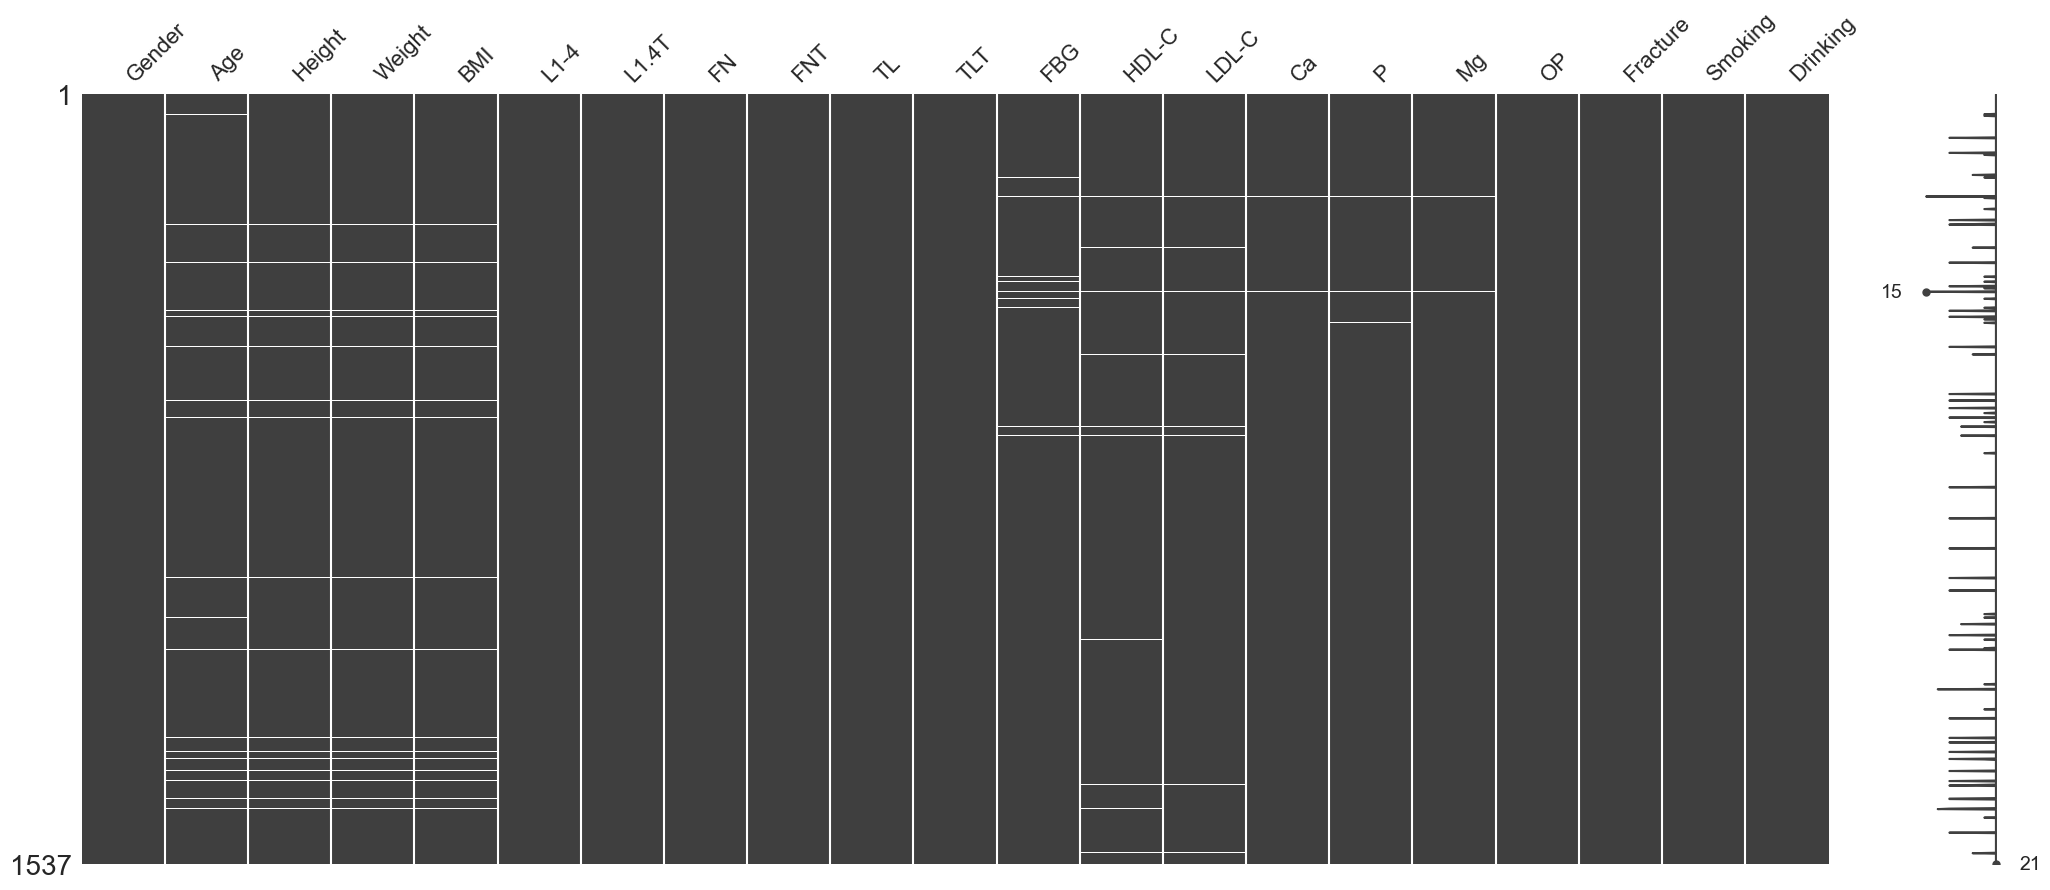

In [25]:
"""
Another visual representation of the missing values per column
"""
msno.matrix(data)

In [26]:
"""
This dataset is a little bit unbalanced, because 63% of the entries are not OP.
It doesn't look like it will be a significant issue, because we can stratify the data when splitting.
"""
data["OP"].value_counts()

OP
0    969
1    568
Name: count, dtype: int64

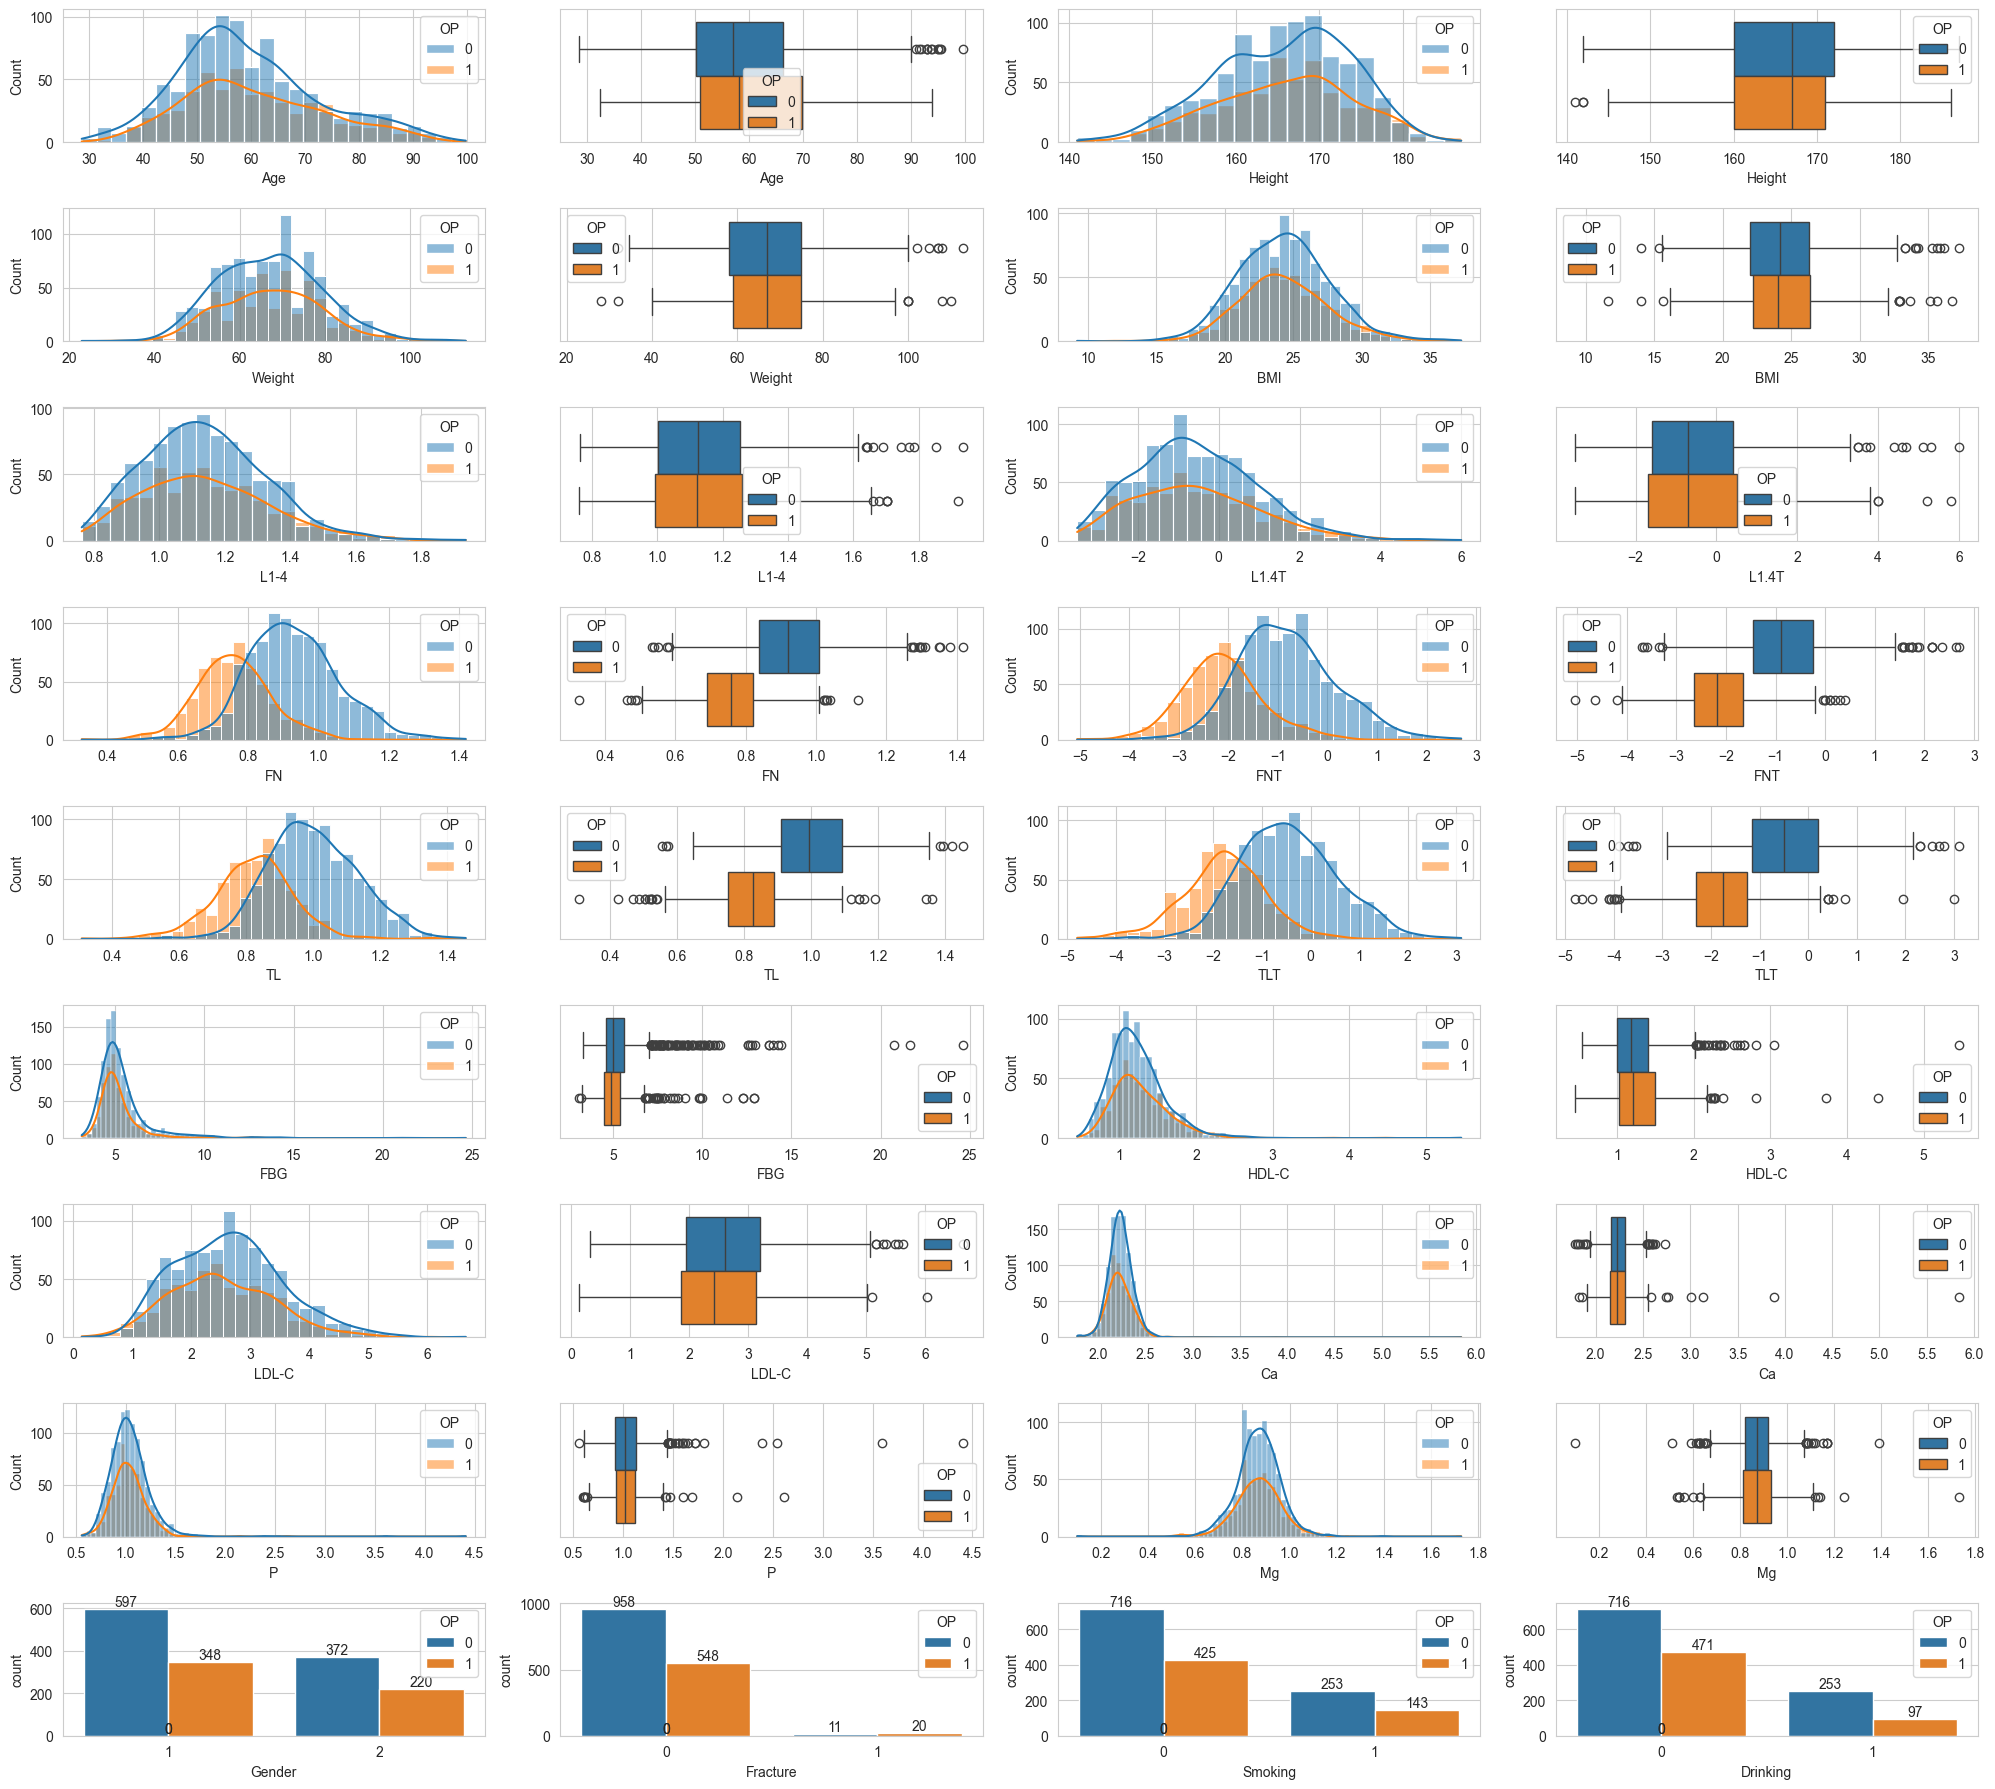

In [27]:
def print_graphs(dataset, title = None):
    hue_column = "OP"
    non_binary_columns = [col for col in dataset.columns if dataset[col].dtype == "float"]
    binary_columns = [col for col in dataset.columns if dataset[col].dtype == "int" and col != hue_column]

    total_plots = (len(non_binary_columns) * 2) + len(binary_columns)
    n_cols = 4
    n_rows = (total_plots + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 2 * n_rows))
    axes = axes.flatten()  # flatten so we can index with a single number

    if title:
        fig.suptitle(title, fontsize=20, y=1.02)

    idx = 0
    for col in non_binary_columns:
        sns.histplot(data=dataset, x=col, hue=hue_column, kde=True, ax=axes[idx])
        idx += 1

        sns.boxplot(data=dataset, x=col, hue=hue_column, ax=axes[idx])
        idx += 1

    for col in binary_columns:
        sns.countplot(data=dataset, x=col, hue=hue_column, ax=axes[idx])

        # Annotate counts on bars
        for p in axes[idx].patches:
            height = p.get_height()
            axes[idx].annotate(f"{int(height)}",(p.get_x() + p.get_width() / 2, height), ha="center", va="bottom")

        idx += 1

    for i in range(idx, len(axes)):
        axes[i].axis("off") # Hide any unused subplots

    plt.tight_layout()
    plt.show()

print_graphs(data)

Looking at these graphs we can see that only some bone measurements, like FN/FNT and TL/TLT, have a clear distinction between OP 0/1. Everything else doesn't seem to vary too much to give us any insight.

According to our reference article:

> Osteoporosis is a “silent” disease because you typically do not have symptoms, and you may not even know you have the disease until you break a bone. Fractures can occur in any bone but happen most often in bones of the hip, vertebrae in the spine, and wrist.

But interestingly enough, we couldn't see any significant differences in number of fractures for OP 1.

Also from reference article, age and lifestyle are factors that could increase the risk of OP:

> Age: As you age, bone loss happens more quickly, and new bone growth is slower. Over time, your bones can weaken and your risk for osteoporosis increases.
>
> Lifestyle: A healthy lifestyle can be important for keeping bones strong. Factors that contribute to bone loss include:
>   - Low levels of physical activity and prolonged periods of inactivity can contribute to an increased rate of bone loss. They also leave you in poor physical condition, which can increase your risk of falling and breaking a bone.
>   - Chronic heavy drinking of alcohol  is a significant risk factor for osteoporosis.
>   - Studies indicate that smoking is a risk factor for osteoporosis and fracture. Researchers are still studying if the impact of smoking on bone health is from tobacco use alone or if people who smoke have more risk factors for osteoporosis.

Our dataset covers a wide range of ages, so it is worth segmenting the data and verify if any correlation changes as age value increases.

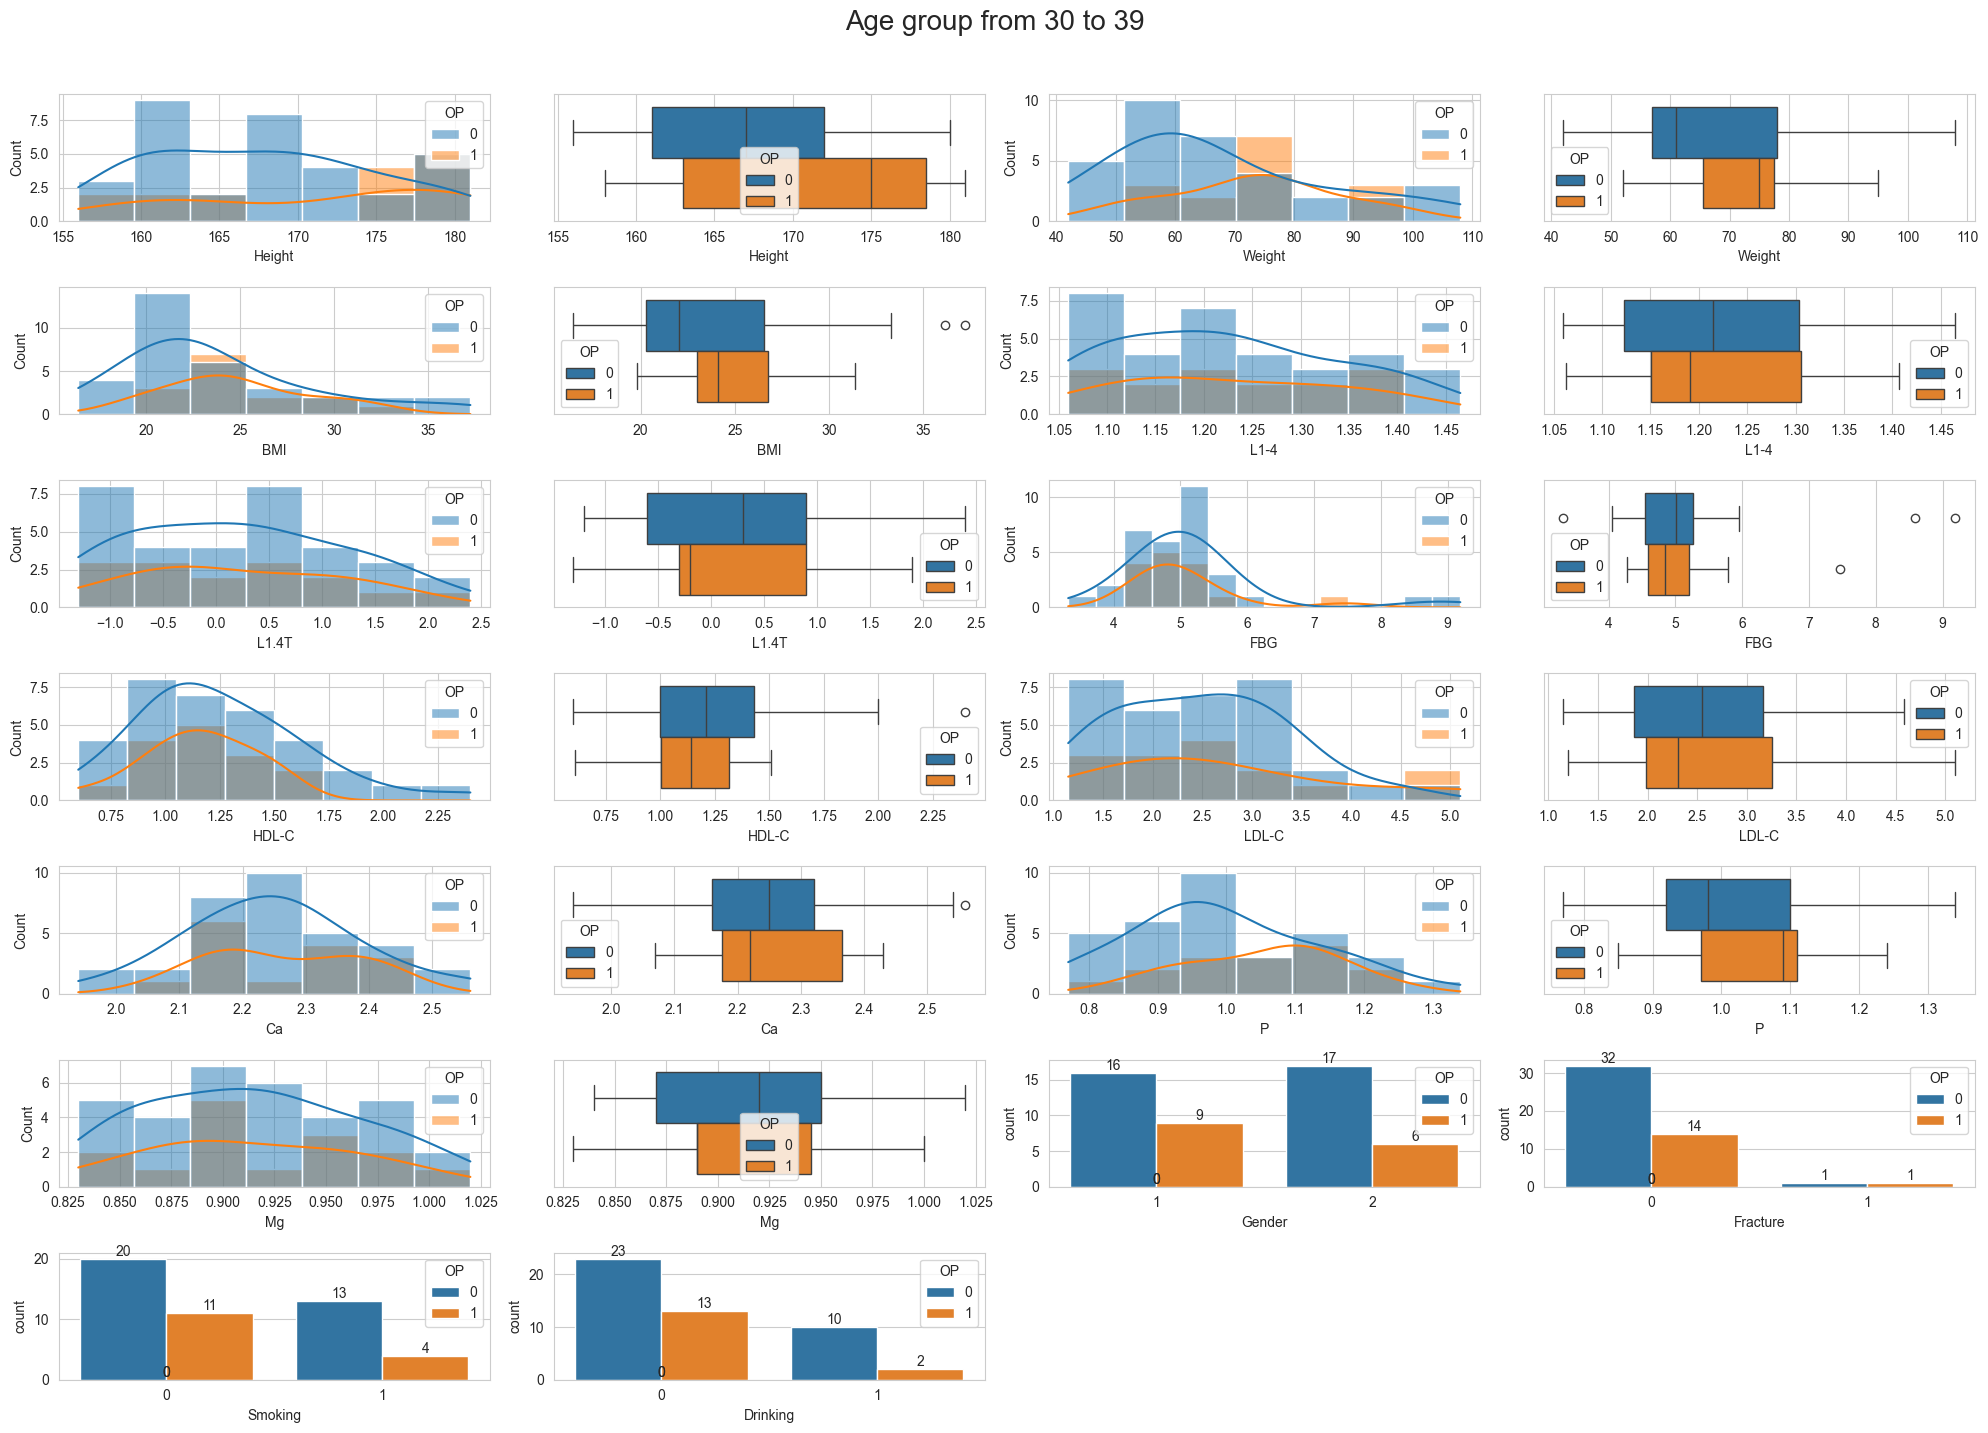

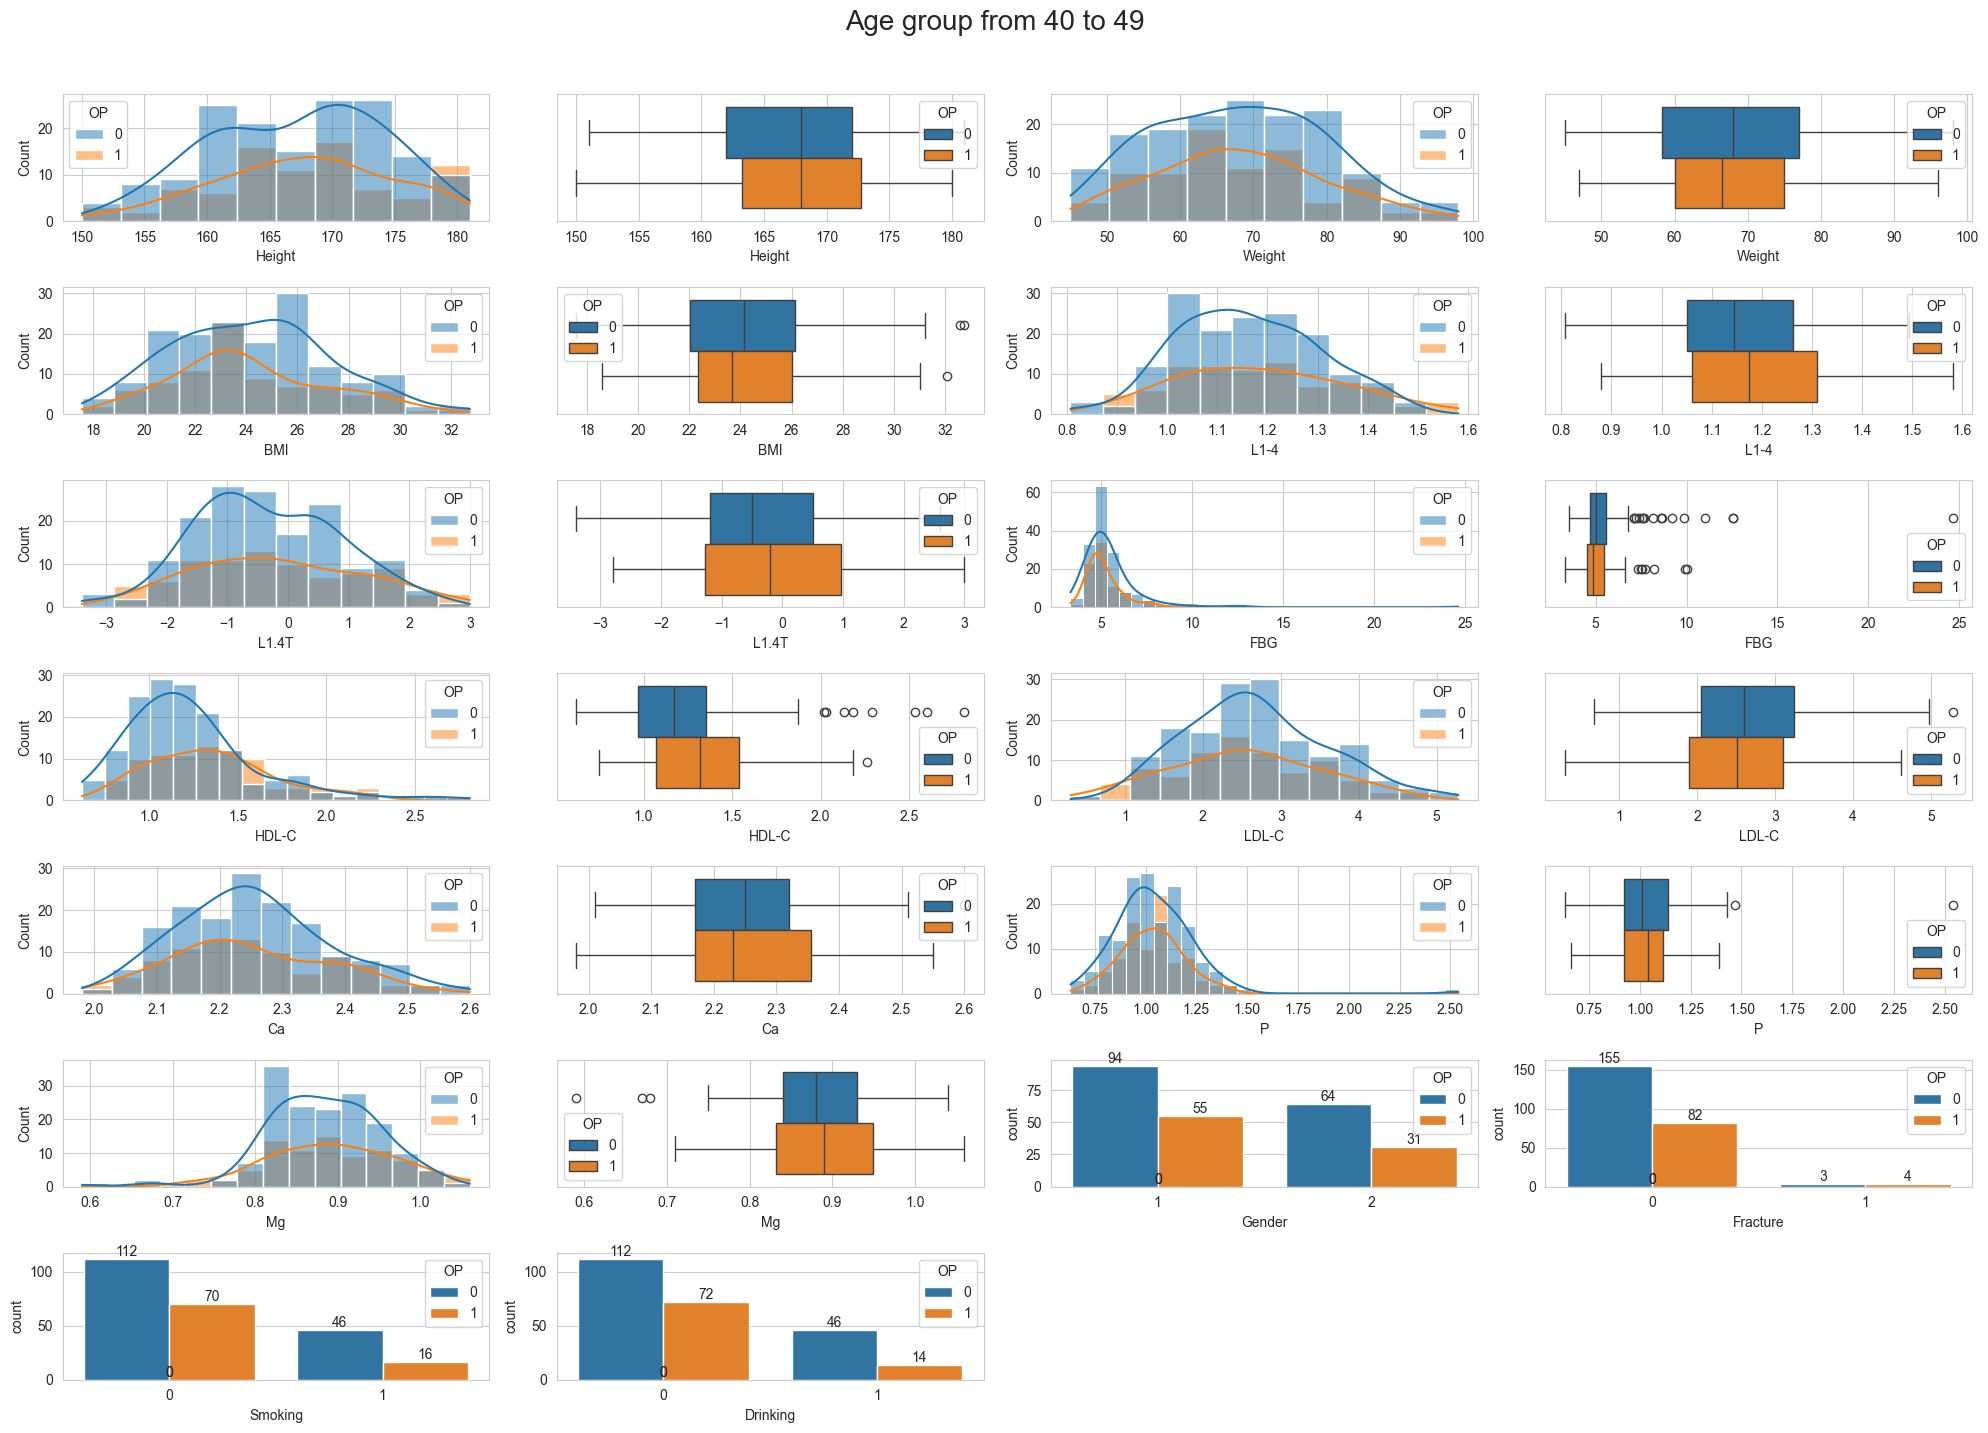

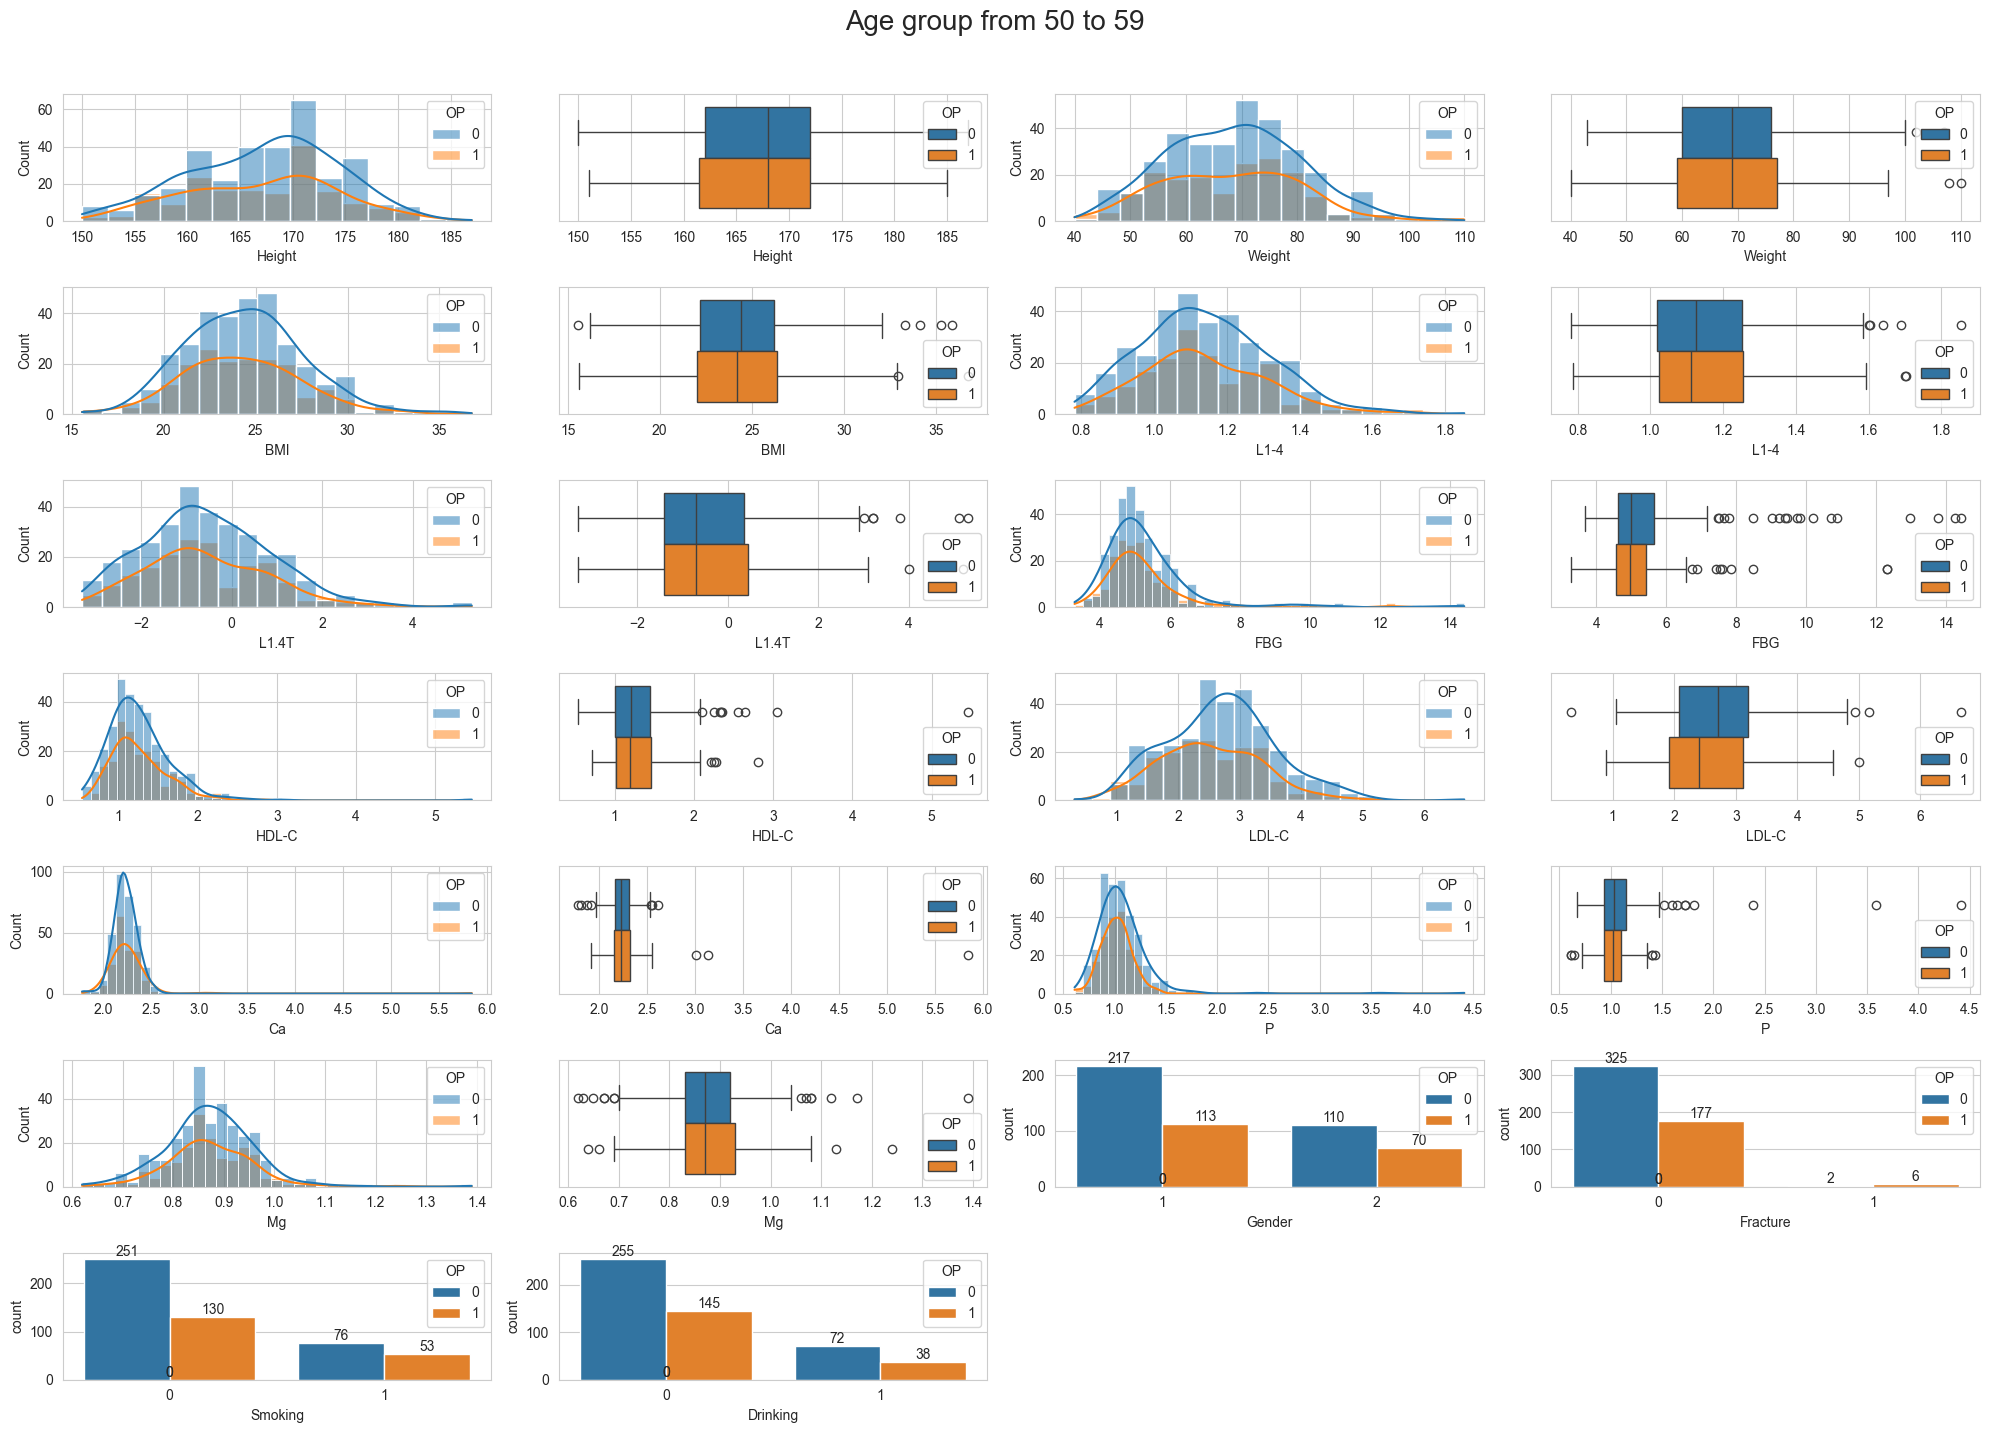

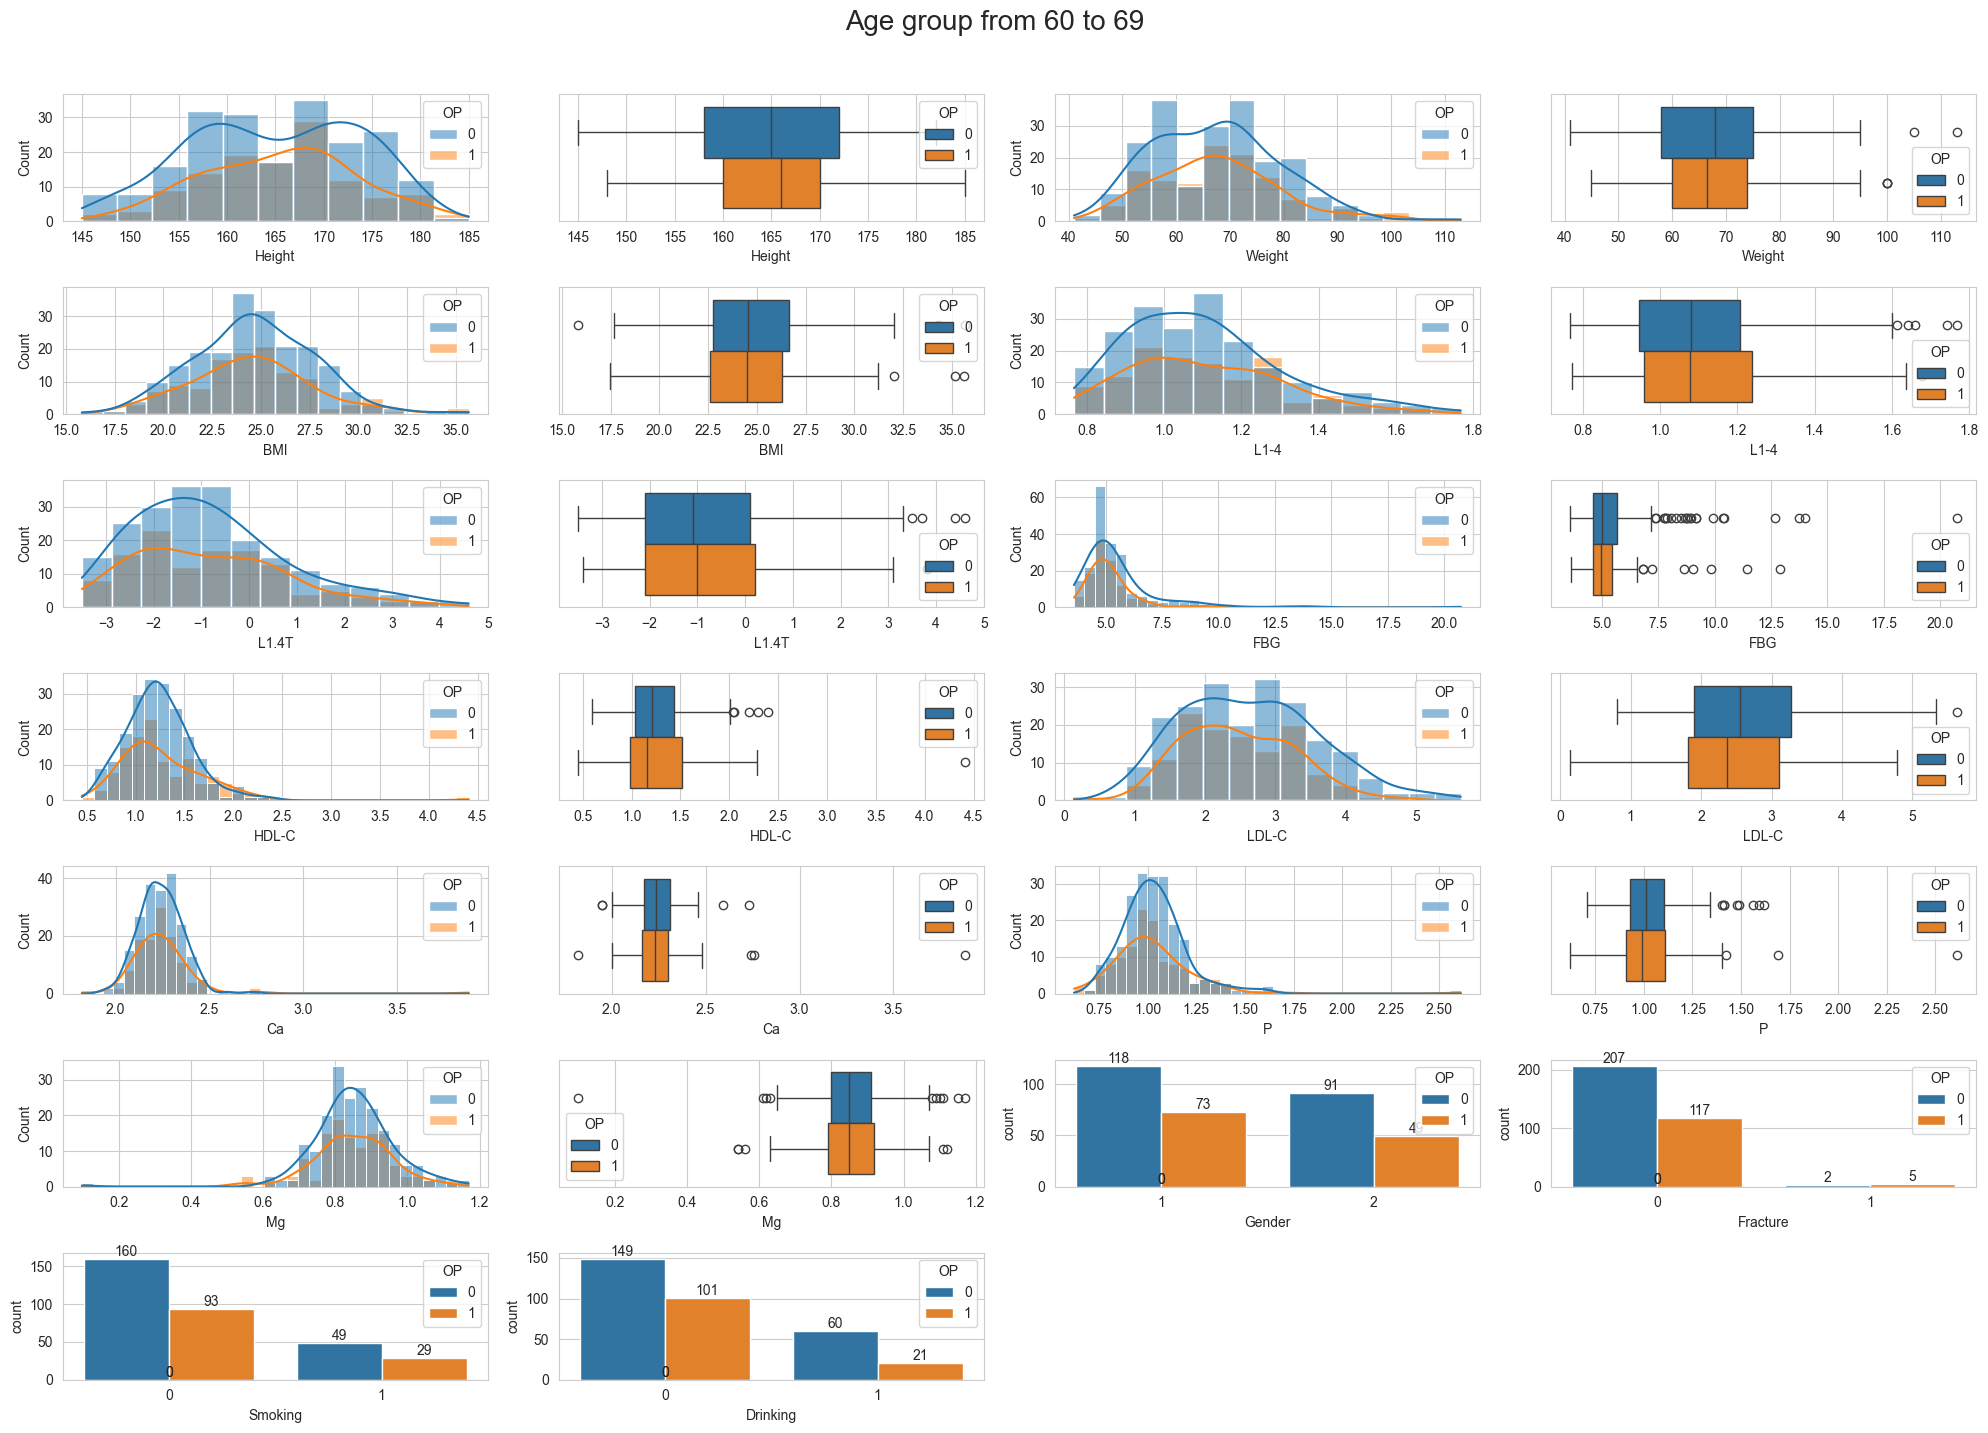

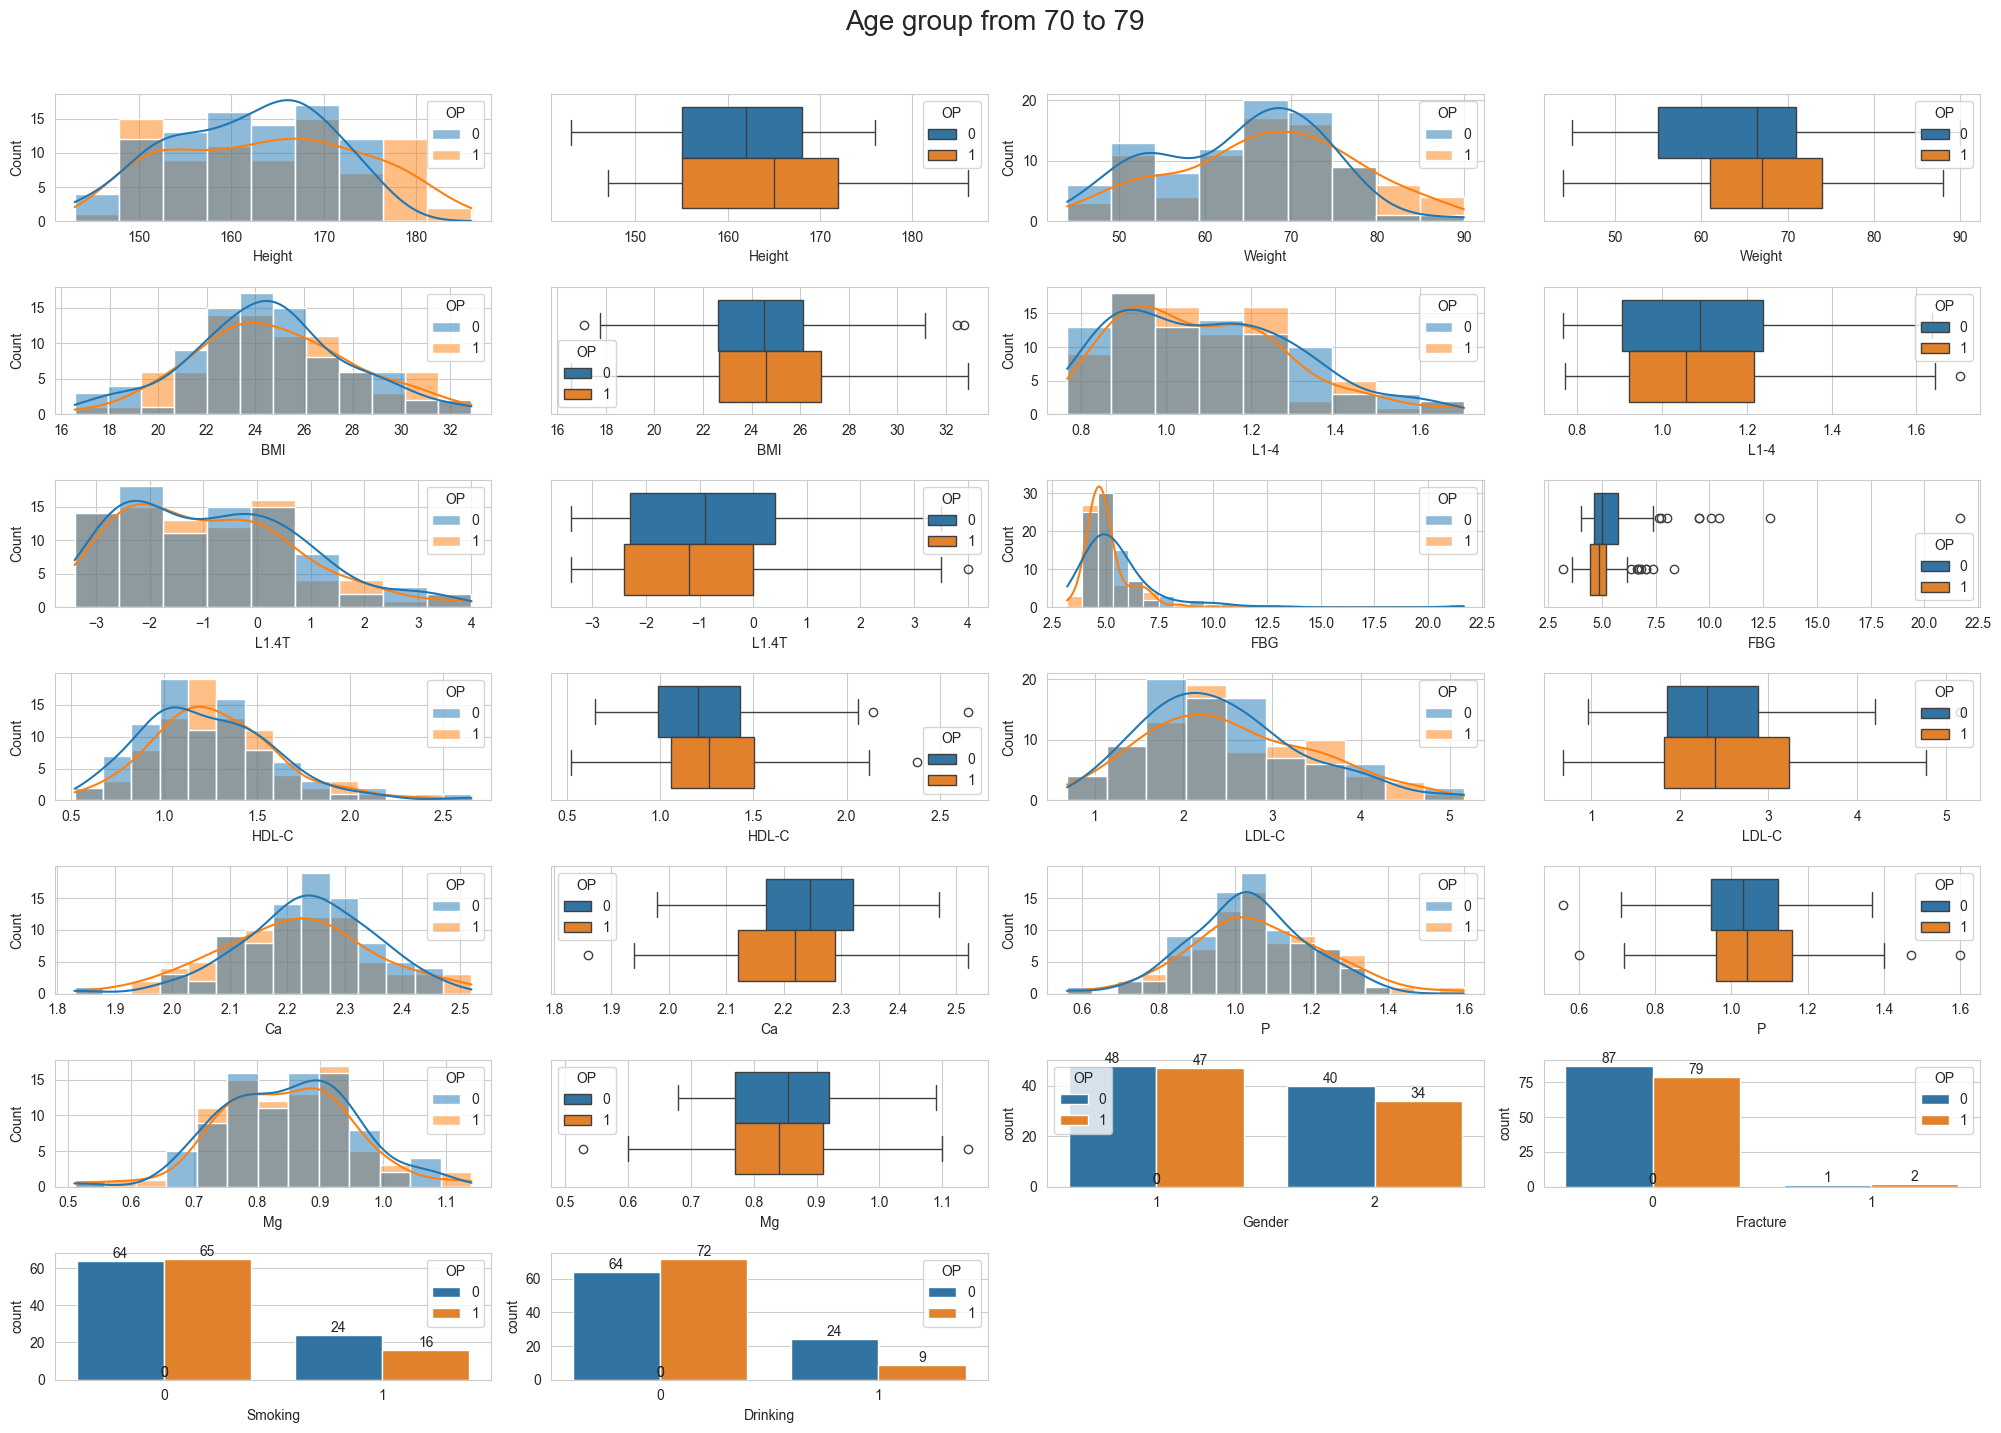

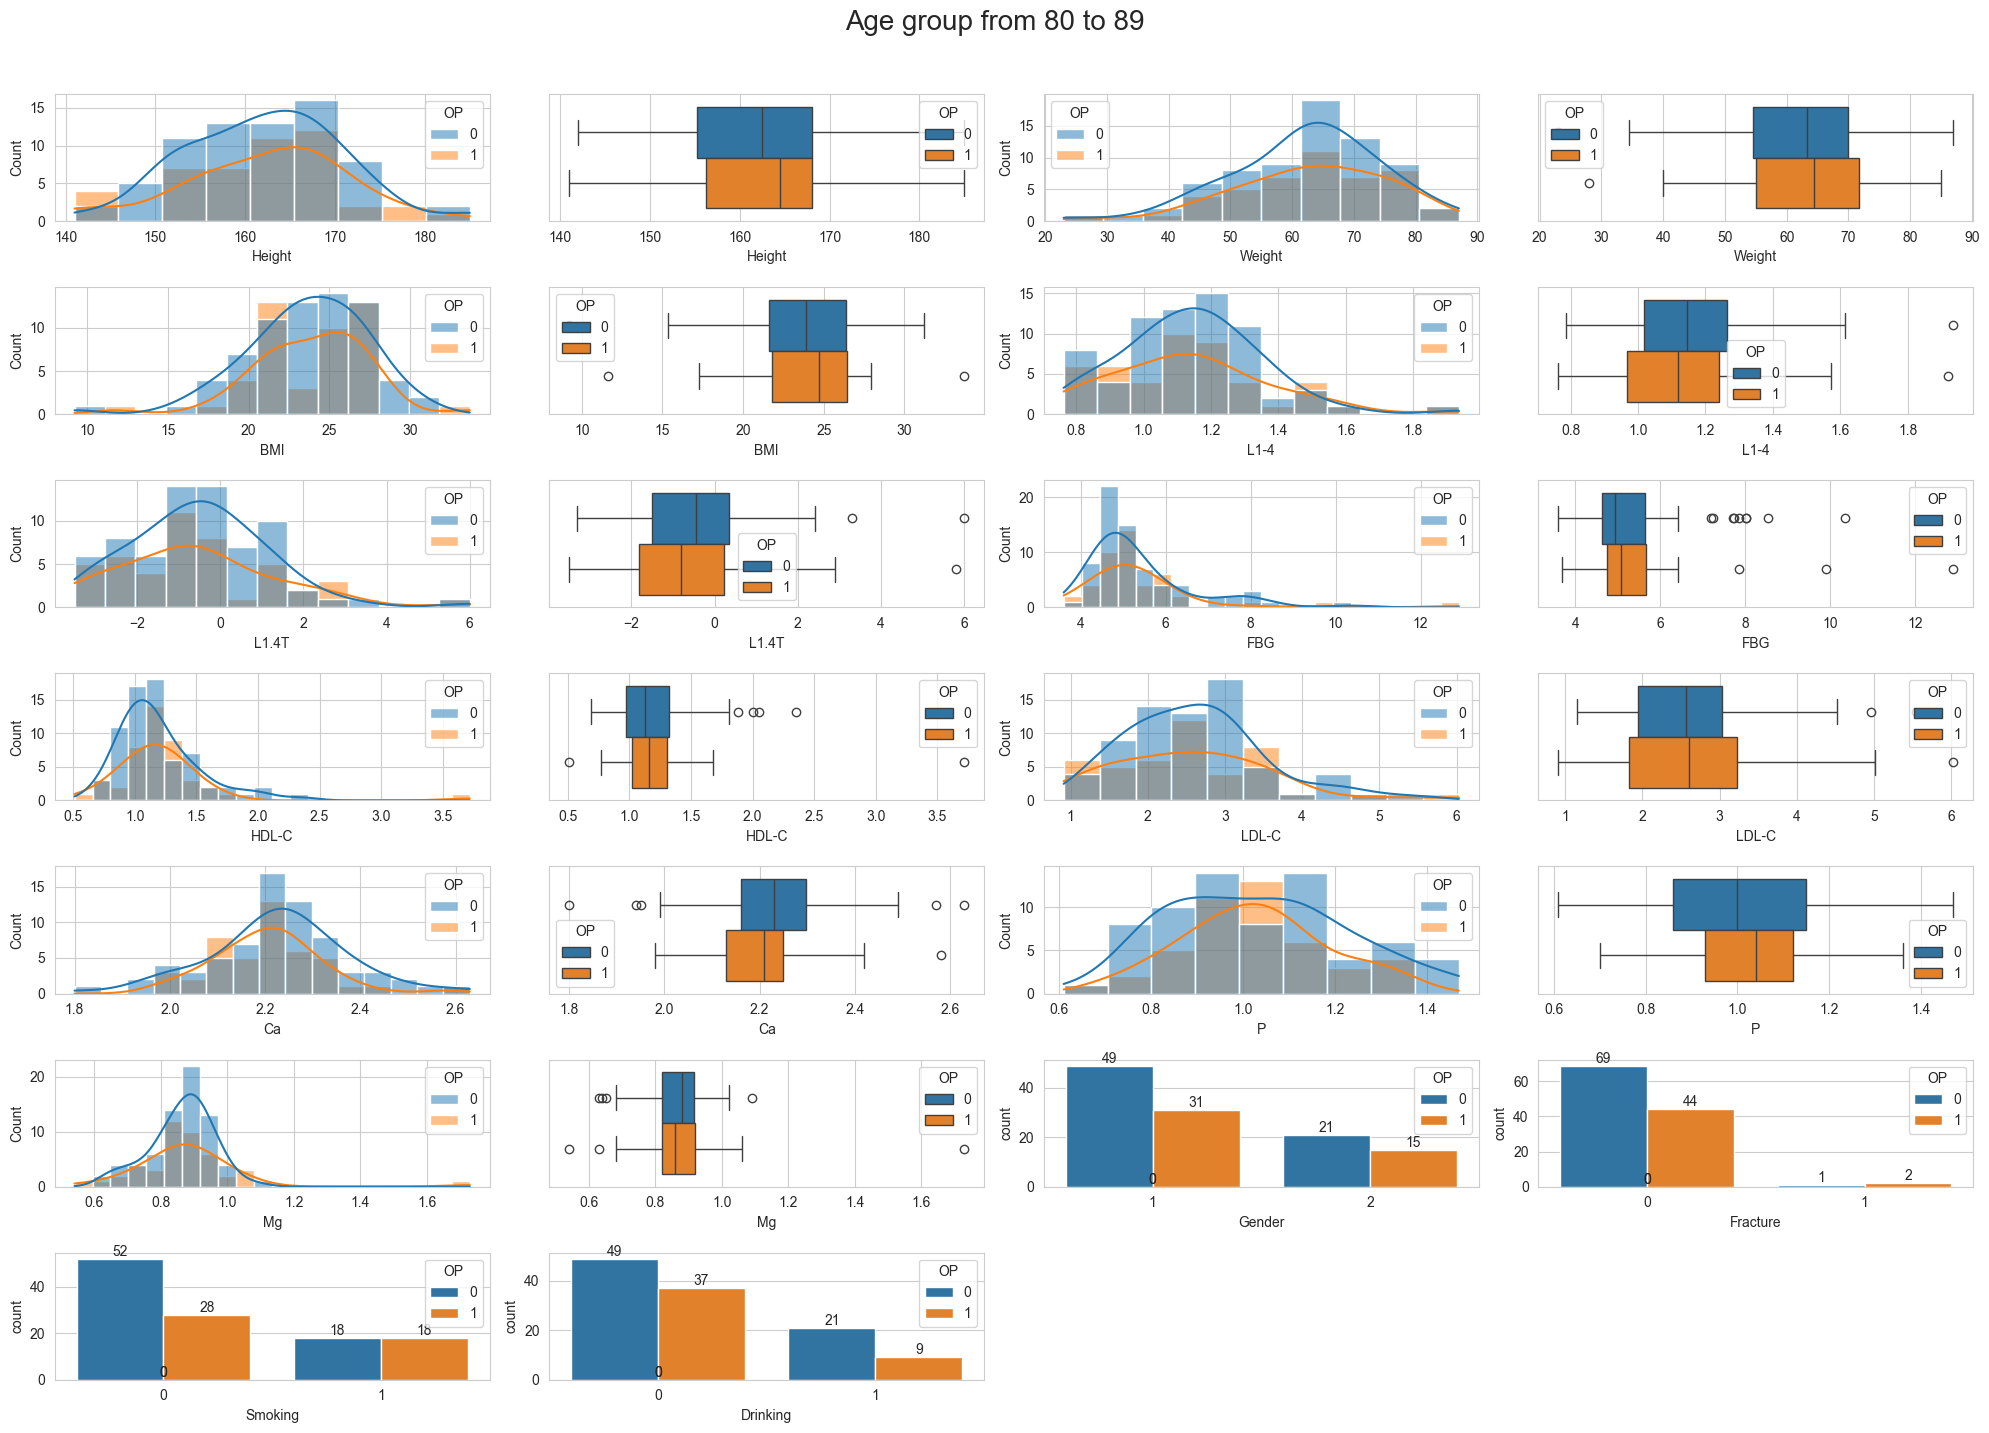

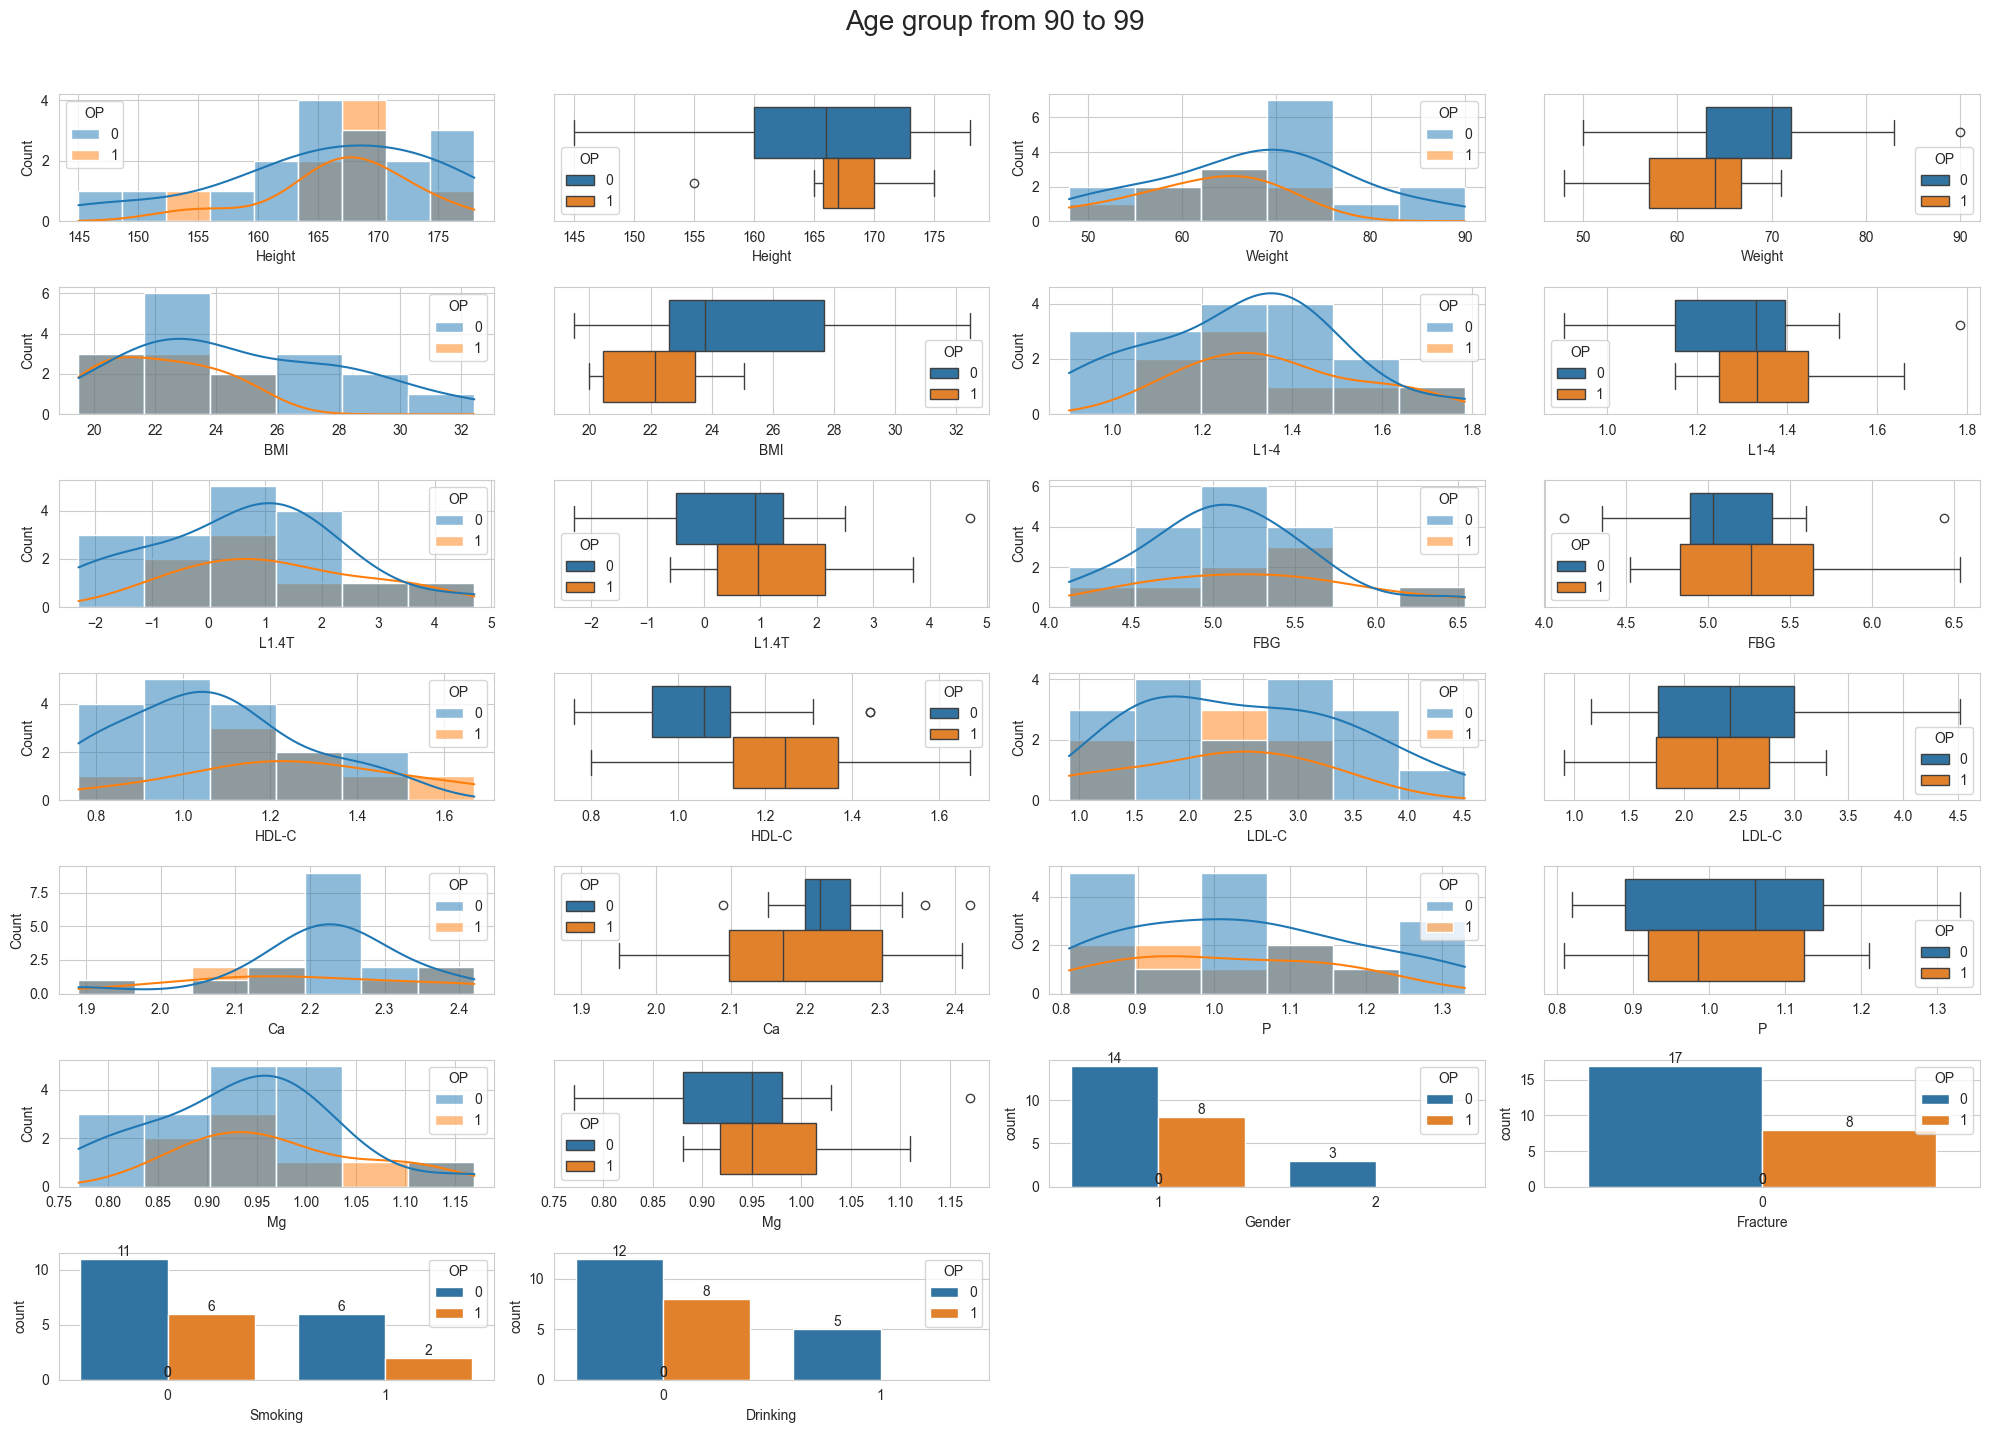

In [28]:
age_ranges = [(30, 39), (40, 49), (50, 59), (60, 69), (70, 79), (80, 89), (90, 99)]
filter_by_age = lambda low, high: data[(data["Age"] >= low) & (data["Age"] <= high)].copy()

for age_range in age_ranges:
    dataset = filter_by_age(age_range[0], age_range[1])
    dataset.drop("Age", axis=1, inplace=True) # We are already using it as ranges
    dataset.drop(["FN", "FNT", "TL", "TLT"], axis=1, inplace=True) # We already know these are strong indicators overall

    print_graphs(dataset, f"Age group from {age_range[0]} to {age_range[1]}")

<Axes: >

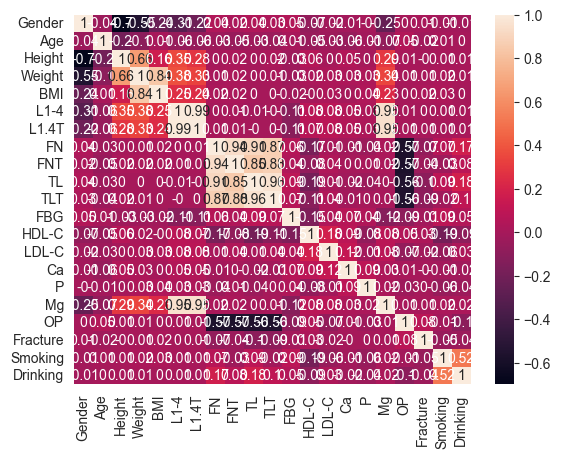

In [29]:
corr_matrix = data.corr(numeric_only=True).round(2)
sns.heatmap(data=corr_matrix, annot=True)